# Tarea 4: Clasificación Multiclase de Esferas Deportivas
Esta libreta aborda la clasificación de 15 tipos de pelotas deportivas.

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp

from scipy import ndimage
from tensorflow.keras.layers import Conv2D, Add, MaxPooling2D, Dense, BatchNormalization, Input, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 1. Configuración de ImageDataGenerator (Carga de Datos)
Definimos los generadores de imágenes para cargar los datos desde los directorios `train` y `test`. Normalizamos los píxeles a la escala [0, 1] dividiendo entre 255.
A diferencia del tutorial de *perros y gatos* (binario), aquí tenemos 15 clases, por lo tanto el `class_mode` será `categorical`.

In [2]:
base_dir = r"c:/Users/Rago/Documents/Development/redes_neuronales/Redes-Neuronales/Semana 4/esferas"
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Configuramos generadores con normalización (rescale=1./255)
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Generador de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# Generador de prueba/validación
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Shuffle en False para poder evaluar la matriz de confusión de manera ordenada
)

class_names = list(train_generator.class_indices.keys())
print("Clases encontradas (15 clases esperadas):", class_names)

Found 7328 images belonging to 15 classes.
Found 1841 images belonging to 15 classes.
Clases encontradas (15 clases esperadas): ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball', 'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock', 'table_tennis_ball', 'tennis_ball', 'volleyball']


## 2. Diseño de la Red Neuronal Convolucional (CNN)

Al igual que en `perrosygatos.ipynb`, usamos la **API Funcional de Keras** para construir la red capa por capa.  
La arquitectura sigue exactamente la misma lógica del tutorial del profesor:  
`Input → Conv2D → Conv2D → MaxPooling2D → ... → Flatten → Dense → Dense (salida)`

La diferencia clave con el tutorial (donde la salida era `Dense(2, activation='softmax')` para perro/gato)  
es que aquí la capa final tiene **15 neuronas**, una por cada tipo de esfera deportiva.

In [ ]:
# ===== DEFINICIÓN DE LA ARQUITECTURA CNN =====

# Capa de entrada: imágenes RGB de 150x150 píxeles (3 canales de color: R, G, B)
inputs = tf.keras.layers.Input(shape=(150, 150, 3))

# --- BLOQUE CONVOLUCIONAL 1 ---
# Conv2D: detecta patrones simples (bordes, esquinas). 32 filtros de 3x3 píxeles
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
# Conv2D: profundiza el aprendizaje de patrones con 64 filtros
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
# MaxPooling2D: reduce el tamaño a la mitad (de 150x150 a ~73x73) 
# tomando el valor máximo en cada ventana 2x2
x = tf.keras.layers.MaxPooling2D(2, 2)(x)

# --- BLOQUE CONVOLUCIONAL 2 ---
# Más filtros para aprender patrones más complejos (texturas, formas)
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2, 2)(x)

# --- BLOQUE CONVOLUCIONAL 3 ---
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2, 2)(x)

# --- CLASIFICADOR (Cabeza densa) ---
# Flatten: "aplana" el mapa de características 3D en un vector 1D
x = tf.keras.layers.Flatten()(x)
# Dense: capa totalmente conectada con 1024 neuronas para combinar todos los patrones aprendidos
x = tf.keras.layers.Dense(1024, activation='relu')(x)
# Capa de salida: 15 neuronas (una por deporte). Softmax convierte los valores en probabilidades que suman 1.
# Diferencia con perros/gatos: allí era Dense(2, ...), aquí es Dense(15, ...)
outputs = tf.keras.layers.Dense(15, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    58,983,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        15,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,571,727 (227.25 MB)

 Trainable params: 59,571,727 (227.25 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Compilación del Modelo

Compilar el modelo significa configurar **cómo aprende**. Se definen tres elementos:
1. **Optimizer (`Adam`):** el algoritmo que actualiza los pesos. En el tutorial se usó `RMSprop`; aquí usamos `Adam` que es una mejora de este mismo concepto.
2. **Loss function (`categorical_crossentropy`):** mide qué tan equivocado estaba el modelo. Como tenemos 15 clases con One-Hot Encoding, usamos `categorical_crossentropy` (en el tutorial binario se usó `sparse_categorical_crossentropy`).
3. **Metrics (`accuracy`):** lo que queremos observar durante el entrenamiento.

In [4]:
# ===== COMPILACIÓN DEL MODELO =====
# optimizer: Adam es un algoritmo eficiente para adaptar el learning rate automáticamente
# loss: categorical_crossentropy es la función de pérdida para clasificación multiclase con One-Hot
# metrics: monitorear la precisión (accuracy) en cada época

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado correctamente.")


Modelo compilado correctamente.


## 4. Entrenamiento del Modelo

Igual que en `perrosygatos.ipynb`, usamos `model.fit()` pasándole el generador de imágenes.  
- **`epochs`**: número de veces que el modelo recorre todo el dataset de entrenamiento.  
- **`validation_data`**: después de cada época, evalúa el modelo en el conjunto de test para detectar overfitting.  

⚠️ El entrenamiento puede tomar varios minutos dependiendo del equipo. ¡Es normal!

In [5]:
# ===== ENTRENAMIENTO DEL MODELO =====
# Igual que en perrosygatos.ipynb, pero con más épocas para un problema más complejo (15 clases)
history = model.fit(
    train_generator,
    epochs=15,                          # 15 pasadas completas sobre el dataset
    validation_data=validation_generator
)


Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 610ms/step - accuracy: 0.0976 - loss: 2.6913 - val_accuracy: 0.1304 - val_loss: 2.5995
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 122s 531ms/step - accuracy: 0.1542 - loss: 2.5261 - val_accuracy: 0.1912 - val_loss: 2.4739
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 120s 526ms/step - accuracy: 0.2271 - loss: 2.3731 - val_accuracy: 0.2504 - val_loss: 2.2907
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 119s 521ms/step - accuracy: 0.3137 - loss: 2.1203 - val_accuracy: 0.3265 - val_loss: 2.1683
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 116s 505ms/step - accuracy: 0.4505 - loss: 1.7254 - val_accuracy: 0.3748 - val_loss: 2.1164
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 116s 507ms/step - accuracy: 0.6093 - loss: 1.2229 - val_accuracy: 0.4340 - val_loss: 2.0382
Epoch 7/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 116s 508ms/step - accuracy: 0.7634 - loss: 0.7395 - val_accuracy: 0.4563 - val_loss: 2.6152
Epoch 8/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 116s 507ms/step - accuracy: 0.8825 -

## 5. Punto 2 — Evaluación del Modelo

Ahora evaluamos qué tan bien funciona el modelo con imágenes que nunca vio durante el entrenamiento  
(las de la carpeta `test`). Calculamos **accuracy** y **loss** de validación, y luego generamos la  
**Matriz de Confusión** para ver exactamente qué tipos de esferas se confunden más entre sí.

Igual que en `perrosygatos.ipynb`, usamos `model.predict()` para obtener las predicciones del modelo  
sobre todas las imágenes de validación.

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ===== OBTENER PREDICCIONES =====
# Reseteamos el generador para que comience desde la primera imagen (recordar shuffle=False)
validation_generator.reset()

# model.predict() pasa TODAS las imágenes de validación por la red y devuelve
# un arreglo de probabilidades: shape = (n_imagenes, 15)
# Cada fila tiene 15 probabilidades que suman 1.0
predictions = model.predict(validation_generator, verbose=1)

# np.argmax selecciona el índice con la probabilidad más alta (la clase predicha)
# Ej: [0.02, 0.03, 0.80, 0.01...] → clase 2 (índice con mayor valor)
y_pred = np.argmax(predictions, axis=1)  # predicciones del modelo (números 0-14)

# Las etiquetas reales vienen del generador (shuffle=False garantiza el mismo orden)
y_true = validation_generator.classes       # etiquetas reales (números 0-14)

# Evaluación general: accuracy y loss en el conjunto de validación
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=0)
print(f"\n--- Evaluación Final en Validación ---")
print(f"Loss de validación:     {val_loss:.4f}")
print(f"Accuracy de validación: {val_accuracy*100:.2f}%")


58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step

--- Evaluación Final en Validación ---
Loss de validación:     5.1167
Accuracy de validación: 49.27%


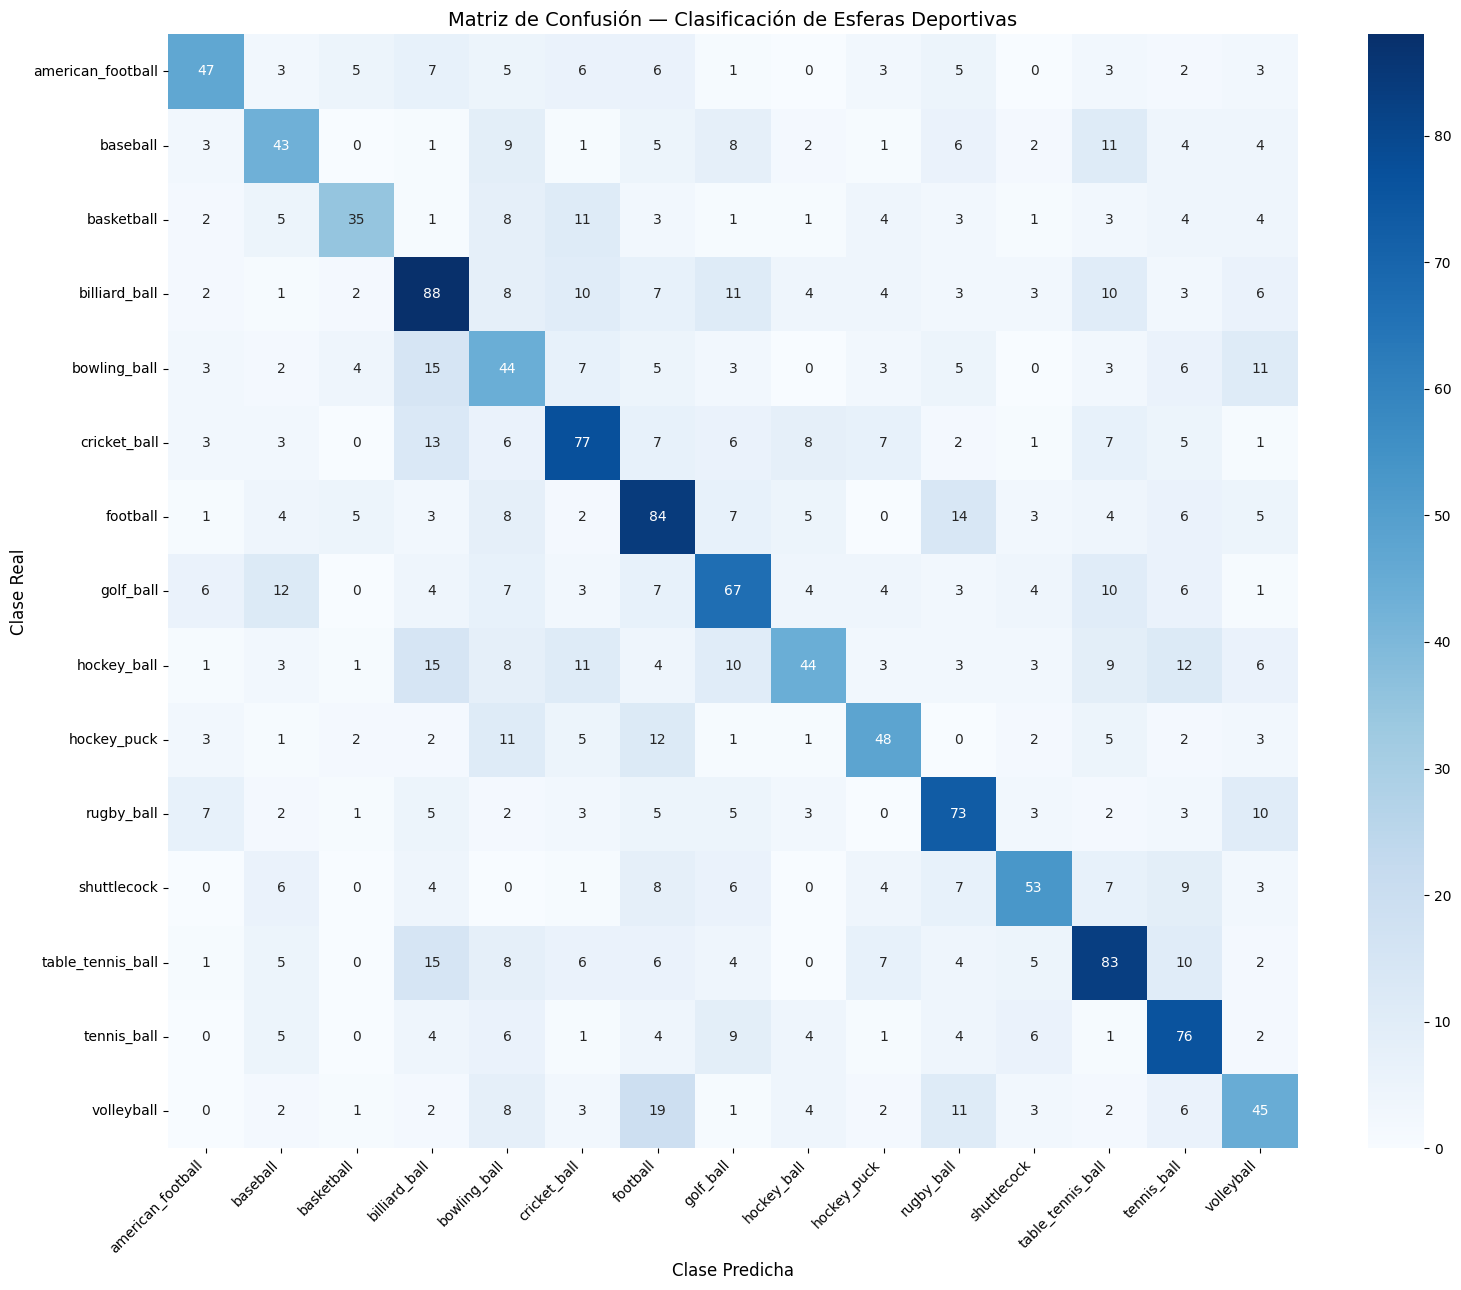

In [7]:
# ===== MATRIZ DE CONFUSIÓN =====
# La matriz de confusión muestra, para cada clase real (filas),
# cuántas imágenes fueron clasificadas en cada clase predicha (columnas).
# Los valores en la DIAGONAL son aciertos. Todo lo demás son errores.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,           # Muestra el número dentro de cada celda
    fmt='d',              # Formato entero (no decimales)
    cmap='Blues',         # Escala de azules: más oscuro = más imágenes en esa celda
    xticklabels=class_names,   # Nombres de clases en el eje X (predicciones)
    yticklabels=class_names    # Nombres de clases en el eje Y (valores reales)
)

plt.title('Matriz de Confusión — Clasificación de Esferas Deportivas', fontsize=14)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
# ===== REPORTE DE CLASIFICACIÓN POR CLASE =====
# El reporte muestra para cada clase:
# - precision: de todas las veces que predijo "X", ¿cuántas eran realmente "X"?
# - recall:    de todas las imágenes reales de "X", ¿cuántas encontró el modelo?
# - f1-score:  promedio armónico de precision y recall (el indicador más equilibrado)

print("\nReporte de Clasificación por Tipo de Esfera:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names))



Reporte de Clasificación por Tipo de Esfera:
                   precision    recall  f1-score   support

american_football       0.59      0.49      0.54        96
         baseball       0.44      0.43      0.44       100
       basketball       0.62      0.41      0.49        86
    billiard_ball       0.49      0.54      0.52       162
     bowling_ball       0.32      0.40      0.35       111
     cricket_ball       0.52      0.53      0.53       146
         football       0.46      0.56      0.50       151
        golf_ball       0.48      0.49      0.48       138
      hockey_ball       0.55      0.33      0.41       133
      hockey_puck       0.53      0.49      0.51        98
       rugby_ball       0.51      0.59      0.55       124
      shuttlecock       0.60      0.49      0.54       108
table_tennis_ball       0.52      0.53      0.53       156
      tennis_ball       0.49      0.62      0.55       123
       volleyball       0.42      0.41      0.42       109

        

## 6. Punto 3 — Visualización de Predicciones

Aquí mostramos imágenes reales del dataset junto con la predicción del modelo.  
Igual que en `perrosygatos.ipynb`, usamos `matplotlib` para mostrar la imagen con su etiqueta real  
y la etiqueta predicha. Si coinciden → **✓ correcto** (en verde). Si no coinciden → **✗ incorrecto** (en rojo).

Esta visualización nos permite ver de forma intuitiva en qué imágenes falla el modelo y por qué.

In [9]:
# ===== FUNCIONES AUXILIARES PARA VISUALIZACIÓN =====
# Necesitamos recargar las imágenes de validación con sus rutas para poder mostrarlas
# Para esto usamos flow_from_directory con una configuración especial

from tensorflow.keras.preprocessing import image as keras_image

def get_images_and_labels(generator, num_images=12):
    """Obtiene un lote de imágenes y sus etiquetas reales del generador."""
    generator.reset()
    images, labels = [], []
    for img_batch, label_batch in generator:
        for img, label in zip(img_batch, label_batch):
            images.append(img)
            labels.append(np.argmax(label))  # convierte One-Hot a número de clase
        if len(images) >= num_images:
            break
    return np.array(images[:num_images]), np.array(labels[:num_images])

# Obtenemos 12 imágenes (un lote pequeño para visualizar)
sample_images, sample_true = get_images_and_labels(validation_generator, 12)

# Predecimos sobre esas 12 imágenes
sample_preds = model.predict(sample_images, verbose=0)
sample_pred_classes = np.argmax(sample_preds, axis=1)     # clase predicha
sample_pred_probs = np.max(sample_preds, axis=1)          # probabilidad más alta

print(f"Imágenes cargadas: {len(sample_images)}")
print(f"Etiquetas reales:   {[class_names[i] for i in sample_true]}")
print(f"Predicciones:       {[class_names[i] for i in sample_pred_classes]}")


Imágenes cargadas: 12
Etiquetas reales:   ['american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football', 'american_football']
Predicciones:       ['american_football', 'bowling_ball', 'american_football', 'american_football', 'american_football', 'baseball', 'cricket_ball', 'american_football', 'american_football', 'american_football', 'american_football', 'rugby_ball']


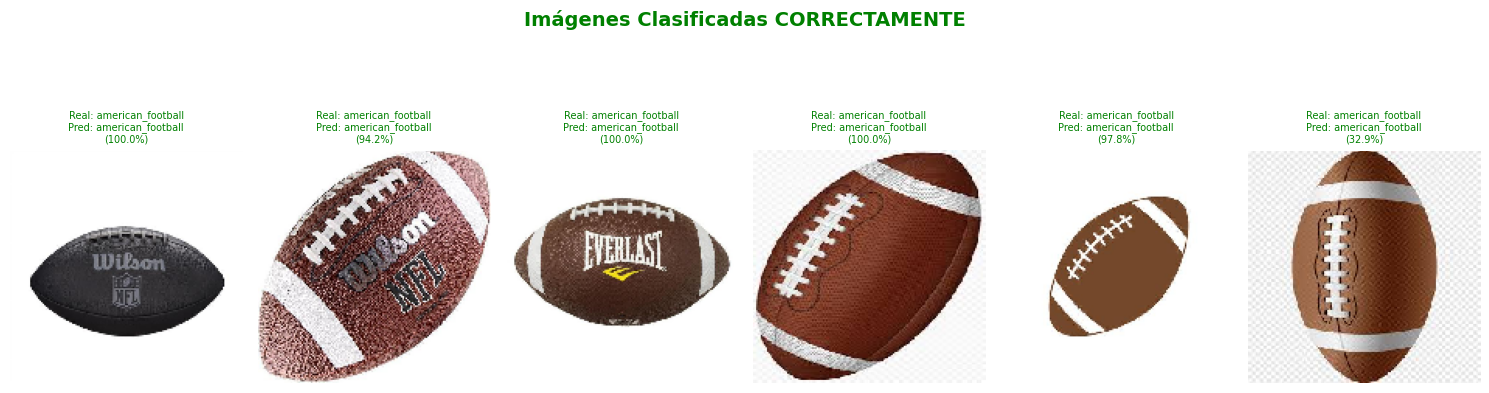

Total correctas en la muestra: 8/12


In [10]:
# ===== IMÁGENES CLASIFICADAS CORRECTAMENTE =====
# Filtramos las imágenes donde la predicción coincide con la etiqueta real
correct_idx = [i for i in range(len(sample_true)) if sample_pred_classes[i] == sample_true[i]]

plt.figure(figsize=(15, 5))
plt.suptitle('Imágenes Clasificadas CORRECTAMENTE', fontsize=14, color='green', fontweight='bold')

shown = 0
for idx in correct_idx[:6]:  # Mostramos hasta 6 ejemplos correctos
    plt.subplot(1, 6, shown + 1)
    plt.imshow(sample_images[idx])
    plt.axis('off')
    # Título verde: predicción correcta con la probabilidad
    plt.title(
        f"Real: {class_names[sample_true[idx]]}\nPred: {class_names[sample_pred_classes[idx]]}\n({sample_pred_probs[idx]*100:.1f}%)",
        color='green', fontsize=7
    )
    shown += 1
    if shown == 6:
        break

plt.tight_layout()
plt.show()
print(f"Total correctas en la muestra: {len(correct_idx)}/{len(sample_images)}")


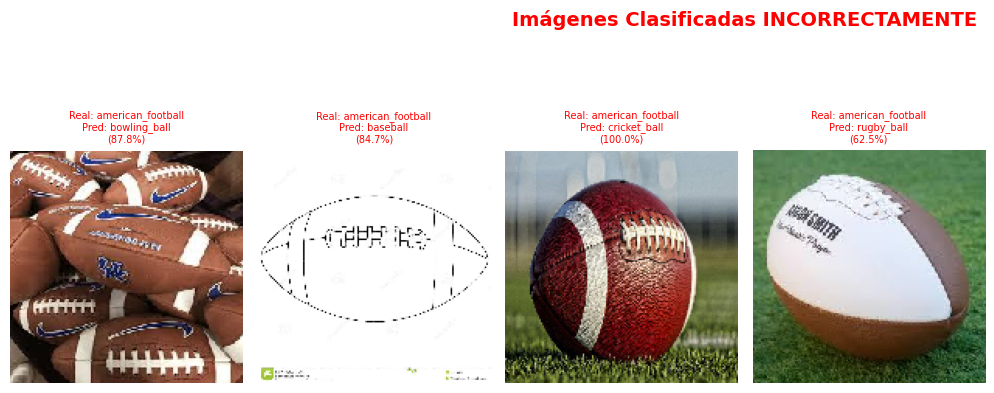

Total incorrectas en la muestra: 4/12


In [11]:
# ===== IMÁGENES CLASIFICADAS INCORRECTAMENTE =====
# Filtramos las imágenes donde la predicción NO coincide con la etiqueta real
incorrect_idx = [i for i in range(len(sample_true)) if sample_pred_classes[i] != sample_true[i]]

plt.figure(figsize=(15, 5))
plt.suptitle('Imágenes Clasificadas INCORRECTAMENTE', fontsize=14, color='red', fontweight='bold')

shown = 0
for idx in incorrect_idx[:6]:  # Mostramos hasta 6 ejemplos incorrectos
    plt.subplot(1, 6, shown + 1)
    plt.imshow(sample_images[idx])
    plt.axis('off')
    # Título rojo: qué era (real) vs qué dijo el modelo (pred)
    plt.title(
        f"Real: {class_names[sample_true[idx]]}\nPred: {class_names[sample_pred_classes[idx]]}\n({sample_pred_probs[idx]*100:.1f}%)",
        color='red', fontsize=7
    )
    shown += 1
    if shown == 6:
        break

plt.tight_layout()
plt.show()
print(f"Total incorrectas en la muestra: {len(incorrect_idx)}/{len(sample_images)}")


## 7. Punto 4 — Visualización del Proceso de Entrenamiento

Graficamos las curvas de **Loss** y **Accuracy** por época, tanto para entrenamiento como para validación.  
Esta técnica es idéntica a la usada en `perrosygatos.ipynb`: el objeto `history` que devolvió `model.fit()`  
guarda internamente todos los valores de cada época en un diccionario.

Estas gráficas son las herramientas visuales definitivas para **diagnosticar overfitting o underfitting**.

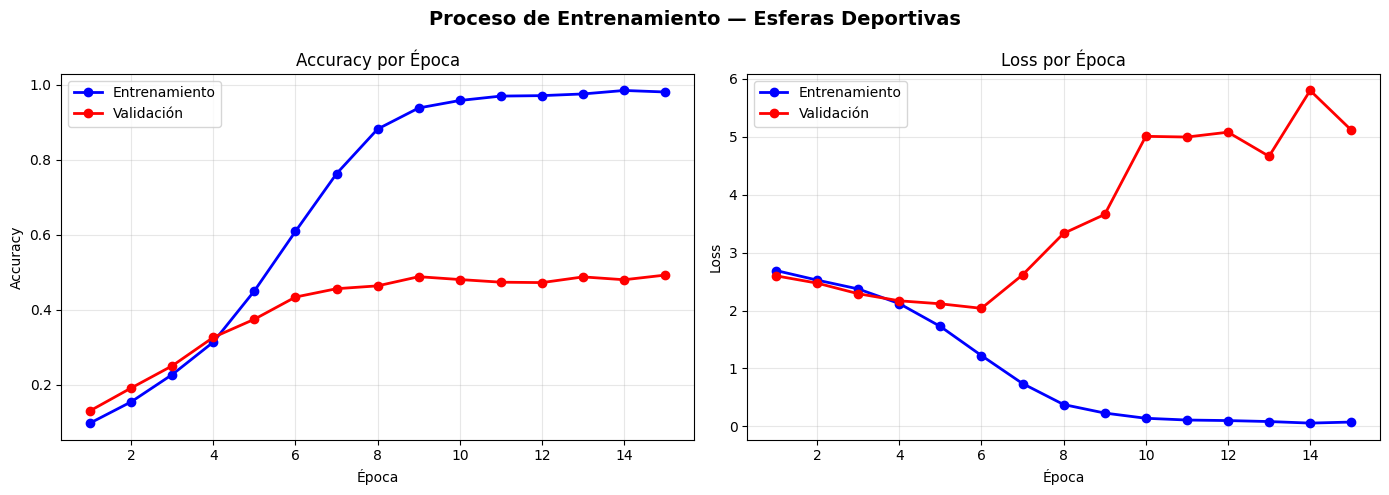

In [12]:
# ===== CURVAS DE ENTRENAMIENTO (Loss y Accuracy por época) =====
# history.history es un diccionario con 4 listas:
#   'accuracy'     → accuracy de entrenamiento en cada época
#   'val_accuracy' → accuracy de validación en cada época
#   'loss'         → loss de entrenamiento en cada época
#   'val_loss'     → loss de validación en cada época

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)  # Eje X: número de época (1, 2, 3 ... 15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Proceso de Entrenamiento — Esferas Deportivas', fontsize=14, fontweight='bold')

# --- GRÁFICA 1: Accuracy ---
axes[0].plot(epochs_range, acc,     'b-o', label='Entrenamiento', linewidth=2)
axes[0].plot(epochs_range, val_acc, 'r-o', label='Validación',    linewidth=2)
axes[0].set_title('Accuracy por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- GRÁFICA 2: Loss ---
axes[1].plot(epochs_range, loss,     'b-o', label='Entrenamiento', linewidth=2)
axes[1].plot(epochs_range, val_loss, 'r-o', label='Validación',    linewidth=2)
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# ===== ANÁLISIS AUTOMÁTICO DE OVERFITTING =====
# Detectamos en qué época el val_loss fue mínimo (punto óptimo de entrenamiento)
best_epoch = val_loss.index(min(val_loss)) + 1  # +1 porque el índice empieza en 0
best_val_acc = val_acc[best_epoch - 1]
best_val_loss = val_loss[best_epoch - 1]

final_acc = acc[-1]
final_val_acc = val_acc[-1]

print("=" * 55)
print("         DIAGNÓSTICO DEL ENTRENAMIENTO")
print("=" * 55)
print(f"\nÉpoca con menor val_loss:  Época {best_epoch}")
print(f"Val_accuracy en ese punto: {best_val_acc*100:.2f}%")
print(f"Val_loss en ese punto:     {best_val_loss:.4f}")
print(f"\nÉpoca final (15):")
print(f"  Train accuracy: {final_acc*100:.2f}%")
print(f"  Val   accuracy: {final_val_acc*100:.2f}%")
gap = final_acc - final_val_acc
print(f"  Brecha (train - val): {gap*100:.2f}%")
if gap > 0.30:
    print("\n⚠️  DIAGNÓSTICO: SOBREAJUSTE (OVERFITTING) SIGNIFICATIVO")
    print(f"   La brecha de {gap*100:.1f}% indica que el modelo memorizó")
    print("   los datos de entrenamiento en lugar de generalizar.")
elif gap > 0.10:
    print("\n⚠️  DIAGNÓSTICO: LEVE SOBREAJUSTE")
else:
    print("\n✅ DIAGNÓSTICO: El modelo generaliza correctamente.")


         DIAGNÓSTICO DEL ENTRENAMIENTO

Época con menor val_loss:  Época 6
Val_accuracy en ese punto: 43.40%
Val_loss en ese punto:     2.0382

Época final (15):
  Train accuracy: 98.13%
  Val   accuracy: 49.27%
  Brecha (train - val): 48.86%

⚠️  DIAGNÓSTICO: SOBREAJUSTE (OVERFITTING) SIGNIFICATIVO
   La brecha de 48.9% indica que el modelo memorizó
   los datos de entrenamiento en lugar de generalizar.
